In [63]:
import sys
import os 

In [64]:
sys.path.append("../src")

In [65]:
from data_load import load_matches
from data_preprocess import extract_deliveries

In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [67]:
data_path = "../data/raw_matches"
matches = load_matches(data_path)
print("Matches loaded:", len(matches))


Number of matches loaded: 1169
Matches loaded: 1169


In [68]:
df = extract_deliveries(matches)
df.head()
# print(type(df))

,match_id,date,team1,team2,venue,over,batter,bowler,runs_batter,runs_total,is_wicket,dismissal_kind,player_out
0,0,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,"Rajiv Gandhi International Stadium, Uppal",0,DA Warner,TS Mills,0,0,0,NaN,NaN
1,0,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,"Rajiv Gandhi International Stadium, Uppal",0,DA Warner,TS Mills,0,0,0,NaN,NaN
2,0,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,"Rajiv Gandhi International Stadium, Uppal",0,DA Warner,TS Mills,4,4,0,NaN,NaN
3,0,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,"Rajiv Gandhi International Stadium, Uppal",0,DA Warner,TS Mills,0,0,0,NaN,NaN
4,0,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,"Rajiv Gandhi International Stadium, Uppal",0,DA Warner,TS Mills,0,2,0,NaN,NaN


In [69]:
rohit_df = df[df["batter"] == "RG Sharma"]
# print(rohit_df)

In [70]:

total_runs = rohit_df["runs_batter"].sum()
balls = len(rohit_df)

strike_rate = (total_runs/balls) * 100

print("Runs:", total_runs)
print("Balls:", balls)
print("Strike Rate:", strike_rate)

Runs: 7048
Balls: 5475
Strike Rate: 128.73059360730593


In [71]:
def phase(over):
    if over <= 5:
        return "Powerplay"
    elif over <=14:
        return "Middle"
    else:
        return "Death"
    
rohit_df["phase"] = rohit_df["over"].apply(phase)

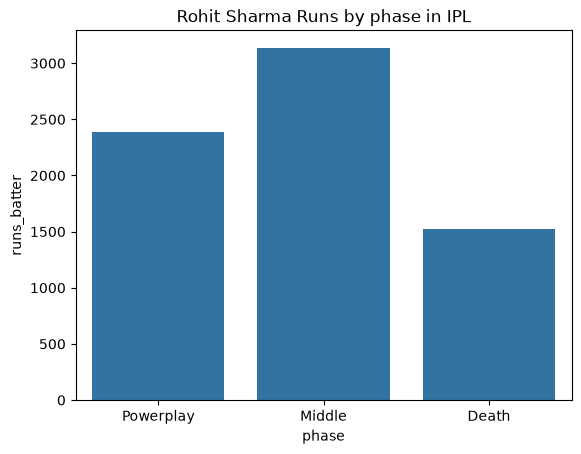

In [72]:
phase_runs = rohit_df.groupby("phase")["runs_batter"].sum()
phase_runs = phase_runs.reset_index()
phase_order = ["Powerplay", "Middle", "Death"]
# print(type(phase_runs))
sns.barplot(
    x="phase", 
    y="runs_batter", 
    data=phase_runs, 
    order=phase_order
    )

plt.title("Rohit Sharma Runs by phase in IPL")
plt.savefig("../charts/phase_runs.png")
plt.show()

Rohit Sharma accumulated the highest total runs during the middle overs. This is likely influenced by two factors: the middle phase spans nine overs (more than the powerplay or death overs), and innings in which he survives the powerplay allow him to spend more deliveries against an older ball.

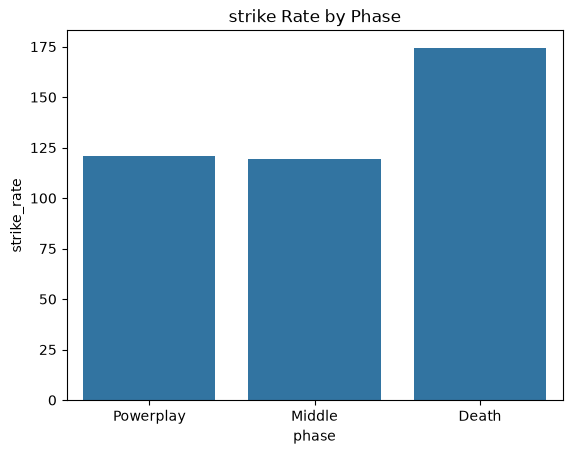

In [73]:
phase_stats = rohit_df.groupby("phase").agg({"runs_batter": "sum","batter": "count"})
phase_order = ["Powerplay", "Middle", "Death"]
phase_stats["strike_rate"] = (phase_stats["runs_batter"] / phase_stats["batter"])*100
sns.barplot(x="phase", y="strike_rate", data=phase_stats, order=phase_order)

plt.title("strike Rate by Phase")
plt.savefig("../charts/strike_rate_phase.png")
plt.show()

Strike rate is highest in Death overs but drops in Powerplay and Middle overs, indicating a slower scoring phase.

In [74]:
# rohit_df["is_boundary"] = rohit_df["runs_batter"].isin([4,6])
# rohit_df["is_dot"] = rohit_df["runs_batter"] == 0

# # boundary_pct = rohit_df["is_boundary"].mean() * 100
# # dot_pct = rohit_df["is_dot"].mean() * 100

# boundary_count = rohit_df["is_boundary"].sum()
# dot_count = rohit_df["is_dot"].sum()

# other_count = len(rohit_df) - boundary_count - dot_count

# labels = ["Boundary %", "Dot Ball %", "Others %"]
# values = [boundary_count, dot_count, other_count]

# plt.pie(values, labels=labels, autopct= "%1.1f%%", startangle = 90)
# plt.title("Boundary vs Dot Ball Percentage")

# plt.savefig("../charts/boundary_dot.png")
# plt.show()

Rohit has a good boundary percentage but also a noticeable number of dot balls, showing phases of pressure.

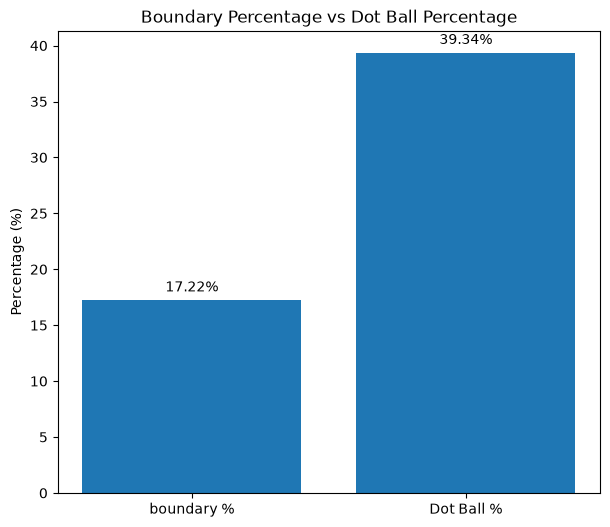

In [75]:
rohit_df["is_boundary"] = rohit_df["runs_batter"].isin([4,6])
rohit_df["is_dot"] = rohit_df["runs_batter"] == 0

boundary_pct = rohit_df["is_boundary"].mean() * 100
dot_pct = rohit_df["is_dot"].mean() * 100

labels = ["boundary %", "Dot Ball %"]
values = [boundary_pct, dot_pct]

plt.figure(figsize=(7,6))
bars = plt.bar(labels, values)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() /2,
        height + 0.5,
        f"{height:.2f}%",
        ha = "center",
        va = "bottom",
        fontsize = 10
    )
plt.ylabel("Percentage (%)")
plt.title("Boundary Percentage vs Dot Ball Percentage")
plt.savefig("../charts/boundary_dot.png")
plt.show()


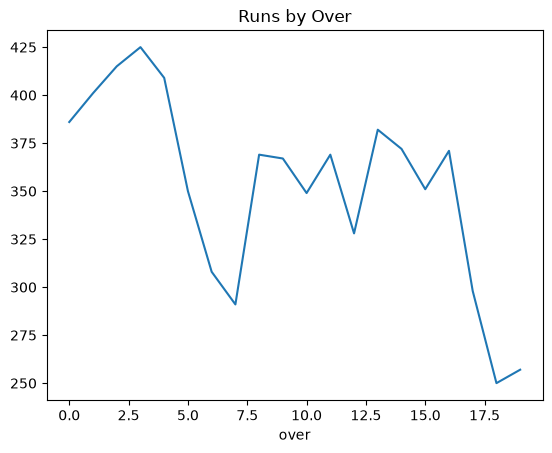

In [76]:
runs_by_over = rohit_df.groupby("over")["runs_batter"].sum()

sns.lineplot(x=runs_by_over.index, y=runs_by_over.values)

plt.title("Runs by Over")
plt.savefig("../charts/runs_by_over.png")
plt.show()

Runs are higher in early overs, slow down in middle overs, and increase again towards the end.

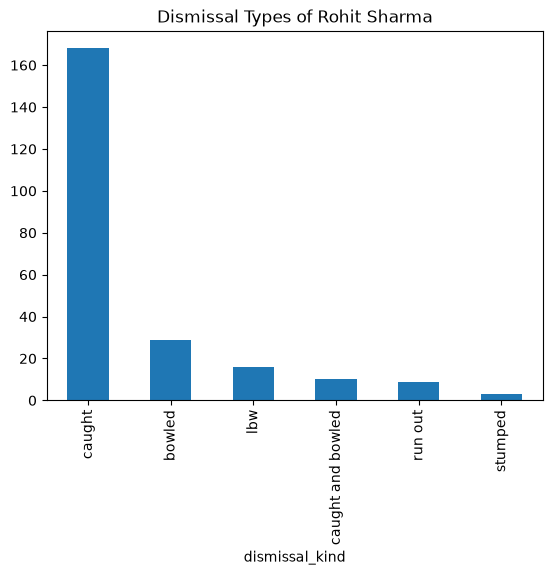

In [77]:
dismissals = rohit_df[
    (rohit_df["player_out"] == "RG Sharma")
]

dismissal_counts = dismissals["dismissal_kind"].value_counts()

dismissal_counts.plot(kind="bar")

plt.title("Dismissal Types of Rohit Sharma")
plt.savefig("../charts/dismissal_types.png")
plt.show()

Most dismissals are catches, indicating aggressive shot selection and risk-taking.

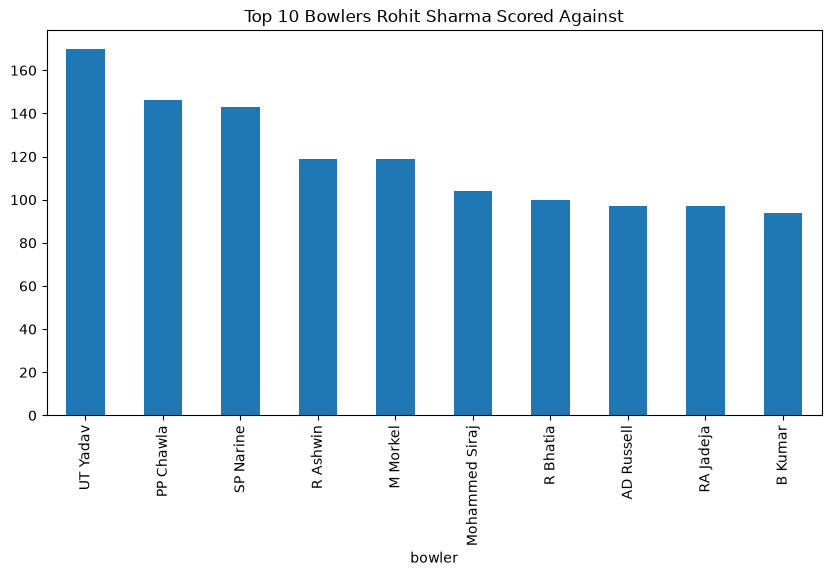

In [78]:
runs_vs_bowler = rohit_df.groupby("bowler")["runs_batter"].sum().sort_values(ascending=False).head(10)

runs_vs_bowler.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Bowlers Rohit Sharma Scored Against")
plt.savefig("../charts/runs_vs_bowler.png")
plt.show()

Rohit has faced some bowlers frequently, which can help analyze specific matchups.

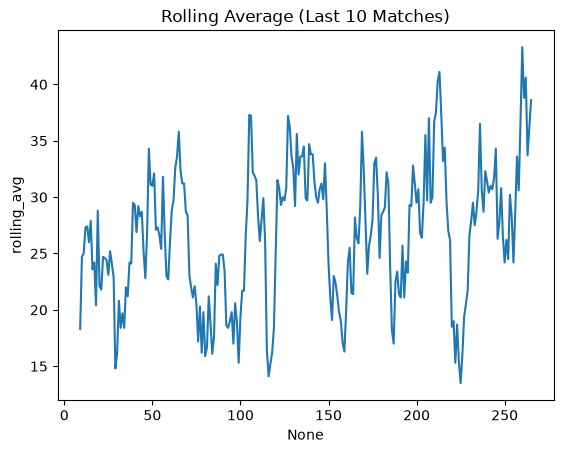

In [79]:
match_runs = rohit_df.groupby("match_id")["runs_batter"].sum().reset_index()

match_runs["rolling_avg"] = match_runs["runs_batter"].rolling(10).mean()

sns.lineplot(x=match_runs.index, y=match_runs["rolling_avg"])

plt.title("Rolling Average (Last 10 Matches)")
plt.savefig("../charts/rolling_avg.png")
plt.show()

The rolling average shows periods of good form followed by dips, indicating streak-based performance.

In [80]:
rohit_df = df[df["batter"] == "RG Sharma"].copy()

# Features
rohit_df["phase"] = rohit_df["over"].apply(phase)
rohit_df["is_boundary"] = rohit_df["runs_batter"].isin([4,6])
rohit_df["is_dot"] = rohit_df["runs_batter"] == 0
rohit_df["year"] = pd.to_datetime(rohit_df["date"]).dt.year
rohit_df["is_out"] = rohit_df["player_out"] == "RG Sharma"

print("Final columns:", rohit_df.columns)

Final columns: Index(['match_id', 'date', 'team1', 'team2', 'venue', 'over', 'batter',
       'bowler', 'runs_batter', 'runs_total', 'is_wicket', 'dismissal_kind',
       'player_out', 'phase', 'is_boundary', 'is_dot', 'year', 'is_out'],
      dtype='str')


In [81]:
final_df = rohit_df[[
    "match_id",
    "date",
    "year",
    "venue",
    "team1",
    "team2",
    "over",
    "phase",
    "bowler",
    "runs_batter",
    "runs_total",
    "is_boundary",
    "is_dot",
    "is_wicket",
    "dismissal_kind",
    "is_out"
]]

In [82]:
final_df.to_csv("../data/processed/rohit_ipl.csv", index=False)

In [83]:
# innings_summary = (
#     rohit_df.groupby(
#         ["match_id", "date", "team1", "team2", "venue"]
#     ).agg(
#         {
#          "runs_batter": "sum",
#          "batter": "count"
#          }
#     ).reset_index()
# )

In [84]:
# filtered_summary = innings_summary[
#     (innings_summary["runs_batter"] > 40) &
#     (innings_summary["batter"].between(25, 40))
# ]

# print(filtered_summary)

